
Archivo: Histograma_Comparativo.png


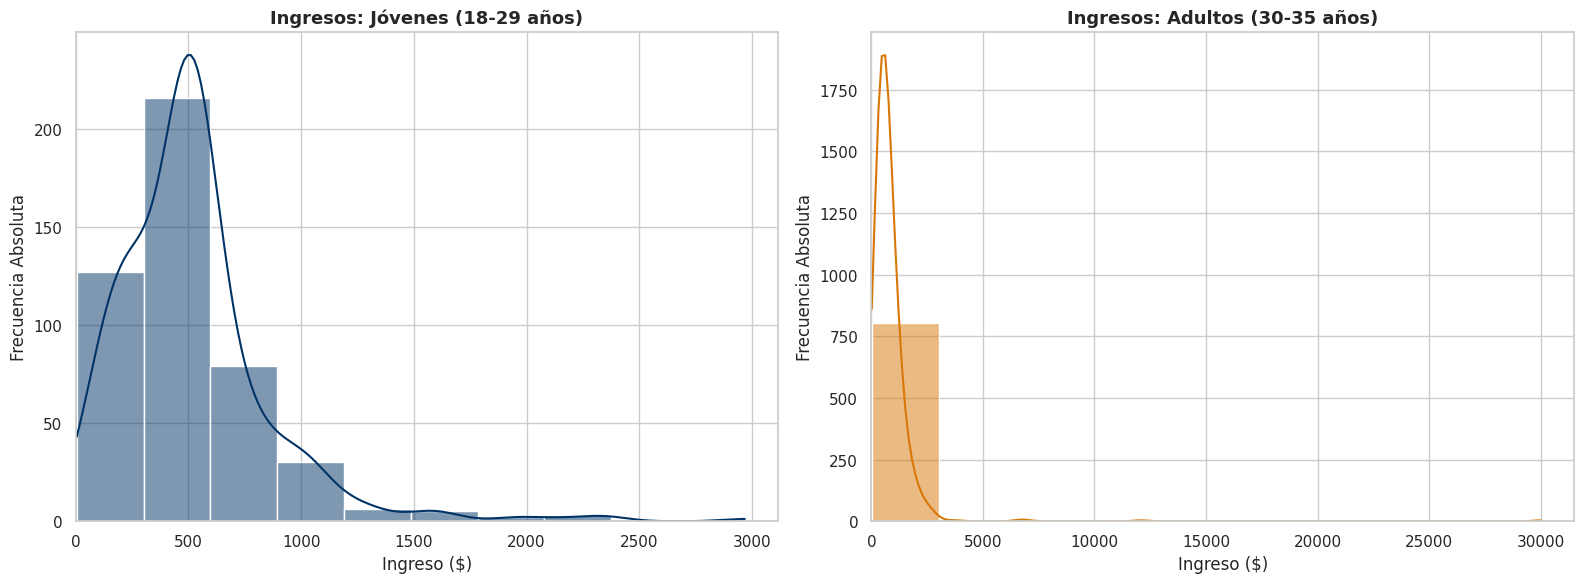


Archivo: Ojiva_Relativa.png


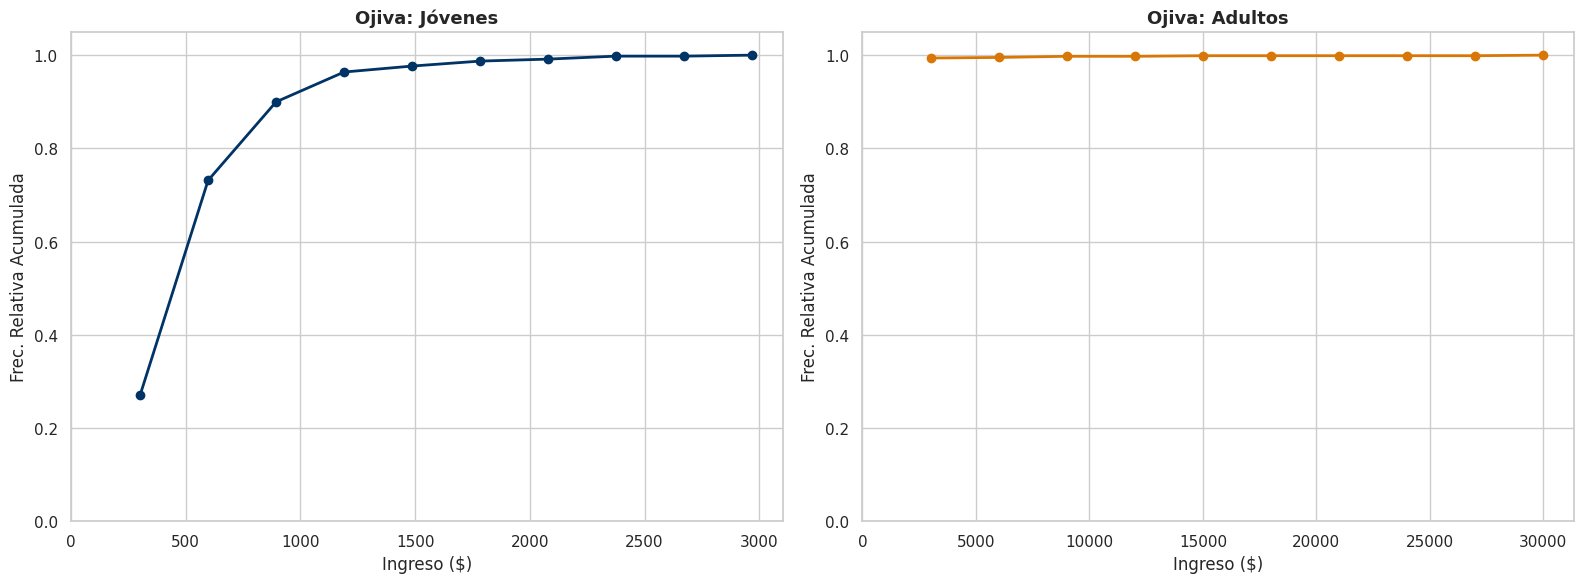


Archivo: Boxplot_Comparativo.png


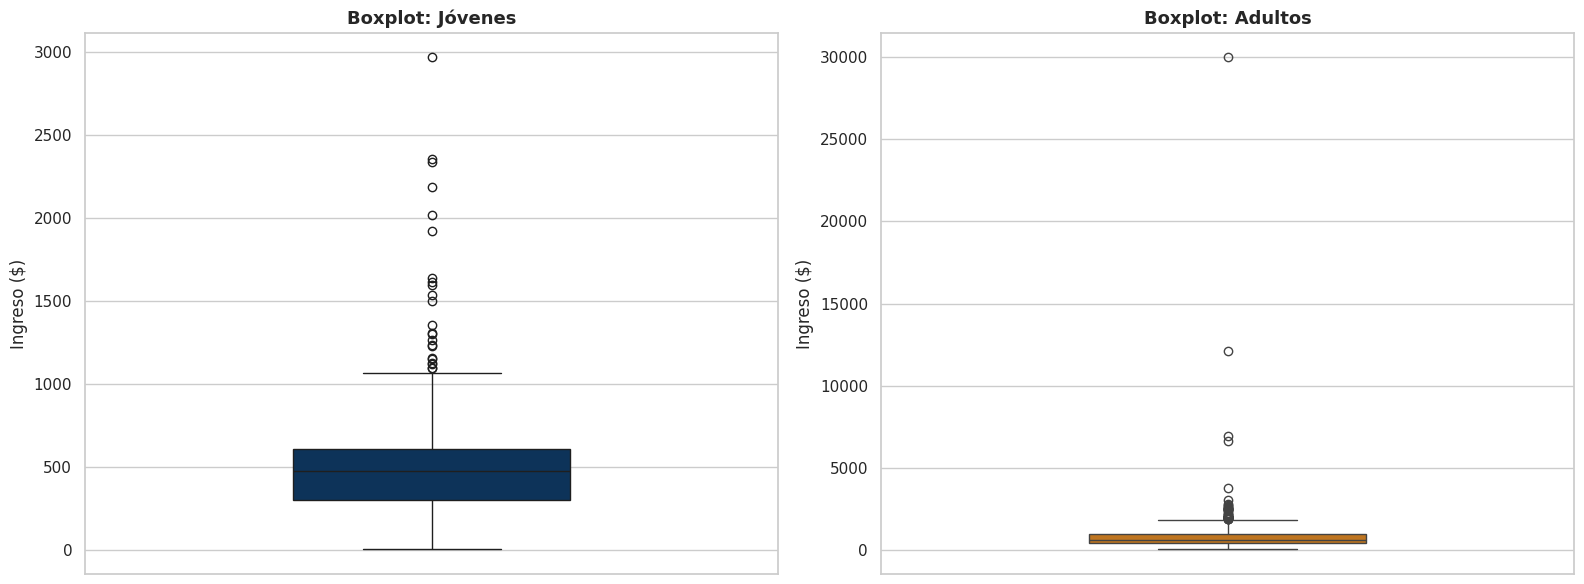

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# =================================================================
# 1. LIMPIEZA Y SEGMENTACIÓN (SECCIÓN 5)
# =================================================================
# Cargamos y filtramos por Pichincha y rangos de edad [cite: 12, 13]
df_full = pd.read_csv('BDDenemdu_personas_2025_anual.csv', sep=';', low_memory=False)
df_pich = df_full[df_full['prov'] == 17].copy()
df_pich['ingrl'] = pd.to_numeric(df_pich['ingrl'], errors='coerce').fillna(0)

# Muestreo balanceado [cite: 16]
df_jovenes = df_pich[(df_pich['p03'] >= 18) & (df_pich['p03'] <= 29)].sample(n=1000, random_state=42)
df_adultos = df_pich[(df_pich['p03'] >= 30) & (df_pich['p03'] <= 35)].sample(n=1000, random_state=42)

# Solo activos para gráficas (Ingresos > 0) [cite: 17]
df_jov_act = df_jovenes[df_jovenes['ingrl'] > 0].copy()
df_adu_act = df_adultos[df_adultos['ingrl'] > 0].copy()

# Guardar datasets [cite: 16]
df_jovenes.to_csv('Dataset_Jovenes_18_29.csv', index=False)
df_adultos.to_csv('Dataset_Adultos_30_35.csv', index=False)

# =================================================================
# 2. HISTOGRAMAS SEPARADOS (Paso 2)
# =================================================================
print("\nArchivo: Histograma_Comparativo.png")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Jóvenes - Ajuste de inicio en 0
sns.histplot(df_jov_act['ingrl'], bins=10, kde=True, color='#003366', ax=axes[0])
axes[0].set_xlim(left=0) # Fuerza inicio en 0
axes[0].set_title('Ingresos: Jóvenes (18-29 años)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ingreso ($)')
axes[0].set_ylabel('Frecuencia Absoluta')

# Adultos - Ajuste de inicio en 0
sns.histplot(df_adu_act['ingrl'], bins=10, kde=True, color='#d97706', ax=axes[1])
axes[1].set_xlim(left=0) # Fuerza inicio en 0
axes[1].set_title('Ingresos: Adultos (30-35 años)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Ingreso ($)')
axes[1].set_ylabel('Frecuencia Absoluta')

plt.tight_layout()
plt.savefig('Histograma_Comparativo.png', dpi=300)
plt.show()

# =================================================================
# 3. OJIVAS RELATIVAS SEPARADAS (Paso 3)
# =================================================================
print("\nArchivo: Ojiva_Relativa.png")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def plot_ojiva_relativa(data, ax, title, color):
    counts, bin_edges = np.histogram(data, bins=10)
    y = np.cumsum(counts) / len(data) # Frecuencia relativa acumulada [cite: 55]
    x = bin_edges[1:]
    ax.plot(x, y, marker='o', color=color, linewidth=2)
    ax.set_ylim(0, 1.05)
    ax.set_xlim(left=0)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Ingreso ($)')
    ax.set_ylabel('Frec. Relativa Acumulada')

plot_ojiva_relativa(df_jov_act['ingrl'], axes[0], 'Ojiva: Jóvenes', '#003366')
plot_ojiva_relativa(df_adu_act['ingrl'], axes[1], 'Ojiva: Adultos', '#d97706')

plt.tight_layout()
plt.savefig('Ojiva_Relativa.png', dpi=300)
plt.show()

# =================================================================
# 4. BOXPLOTS SEPARADOS (Paso 4)
# =================================================================
print("\nArchivo: Boxplot_Comparativo.png")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Jóvenes [cite: 112]
sns.boxplot(y=df_jov_act['ingrl'], color='#003366', ax=axes[0], width=0.4)
axes[0].set_title('Boxplot: Jóvenes', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Ingreso ($)')

# Boxplot Adultos [cite: 112]
sns.boxplot(y=df_adu_act['ingrl'], color='#d97706', ax=axes[1], width=0.4)
axes[1].set_title('Boxplot: Adultos', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Ingreso ($)')

plt.tight_layout()
plt.savefig('Boxplot_Comparativo.png', dpi=300)
plt.show()